In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tsla = pd.read_csv("../data/processed/TSLA.csv", index_col="Date", parse_dates=True)
tsla = tsla.asfreq("B")       # explicitly tell pandas this is business-day frequency
tsla["Close"] = tsla["Close"].ffill()  # in case asfreq introduced any gap rows
tsla["Daily Return"] = tsla["Close"].pct_change()

tsla.head()

,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000.0,NaN
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500.0,-0.042041
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500.0,0.005664
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000.0,-0.001562
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500.0,-0.001564


In [2]:
train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

print(f"Train period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test period:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

Train period: 2015-01-02 to 2024-12-31 (2608 rows)
Test period:  2025-01-01 to 2026-06-29 (389 rows)


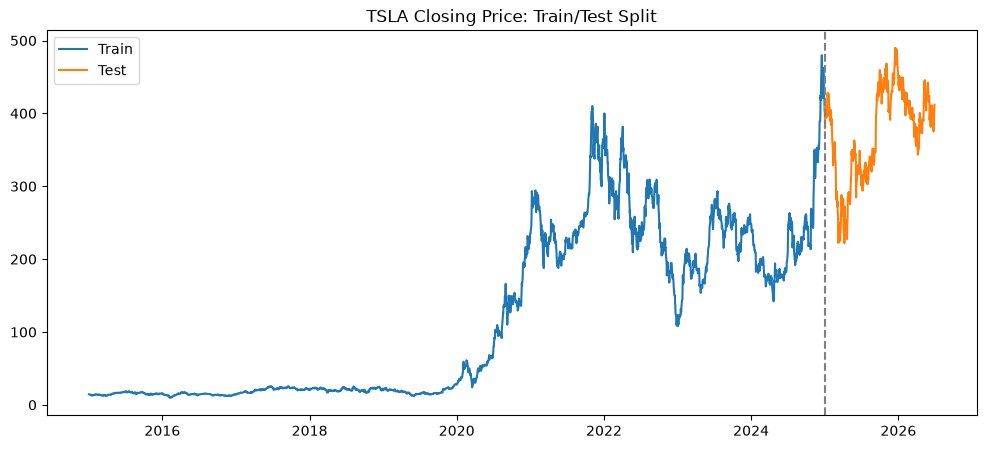

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Close"], label="Train")
plt.plot(test.index, test["Close"], label="Test")
plt.axvline(x=test.index.min(), color="gray", linestyle="--")
plt.title("TSLA Closing Price: Train/Test Split")
plt.legend()
plt.savefig("../data/processed/train_test_split.png", dpi=150)
plt.show()

In [4]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train["Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,               # let auto_arima determine 'd' via statistical tests
    seasonal=False,       # we'll treat this as non-seasonal for the baseline ARIMA
    stepwise=True,
    trace=True,           # print each combination it tries
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=9.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.63 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.87 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.53 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 15.479 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Thu, 09 Jul 2026   AIC                          16873.127
Time:                        21:41:37   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                 

In [5]:
from statsmodels.tsa.arima.model import ARIMA

order = auto_model.order  # grabs the (p,d,q) auto_arima found, e.g. (0,1,0)
print(f"Using order: {order}")

model = ARIMA(train["Close"], order=order)
fitted_model = model.fit()

# Forecast for the entire test period length
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

forecast_mean.index = test.index
conf_int.index = test.index

print(forecast_mean.head())

Using order: (0, 1, 0)
Date
2025-01-01    403.839996
2025-01-02    403.839996
2025-01-03    403.839996
2025-01-06    403.839996
2025-01-07    403.839996
Freq: B, Name: predicted_mean, dtype: float64


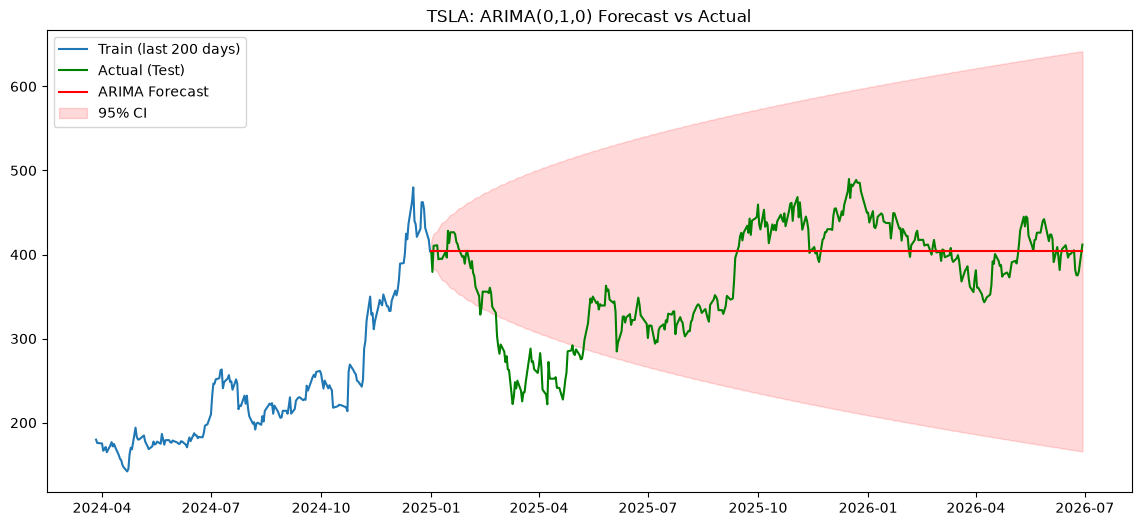

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-200:], train["Close"].iloc[-200:], label="Train (last 200 days)")
plt.plot(test.index, test["Close"], label="Actual (Test)", color="green")
plt.plot(forecast_mean.index, forecast_mean, label="ARIMA Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.15, label="95% CI")
plt.title("TSLA: ARIMA(0,1,0) Forecast vs Actual")
plt.legend()
plt.savefig("../data/processed/arima_forecast.png", dpi=150)
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test["Close"]
predicted = forecast_mean

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  54.15
RMSE: 70.20
MAPE: 17.11%
